Cats: 1000 | Dogs: 1000 | Total: 2000
Variance retained by PCA: 83.87%
Train: 1600 | Test: 400

Training SVM...
Training complete.

Accuracy: 57.50%

Classification Report:
              precision    recall  f1-score   support

         Cat       0.58      0.56      0.57       200
         Dog       0.57      0.59      0.58       200

    accuracy                           0.57       400
   macro avg       0.58      0.57      0.57       400
weighted avg       0.58      0.57      0.57       400



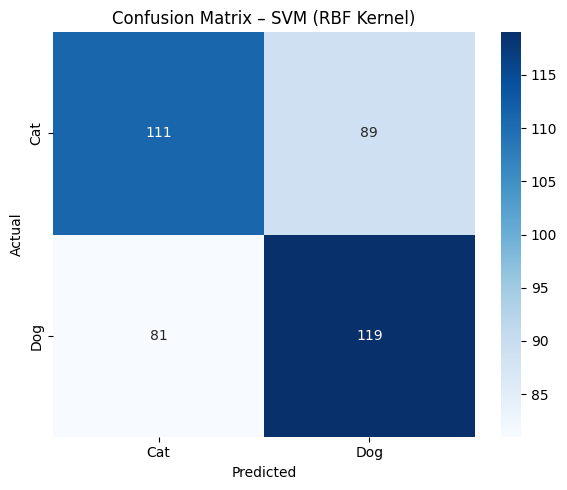

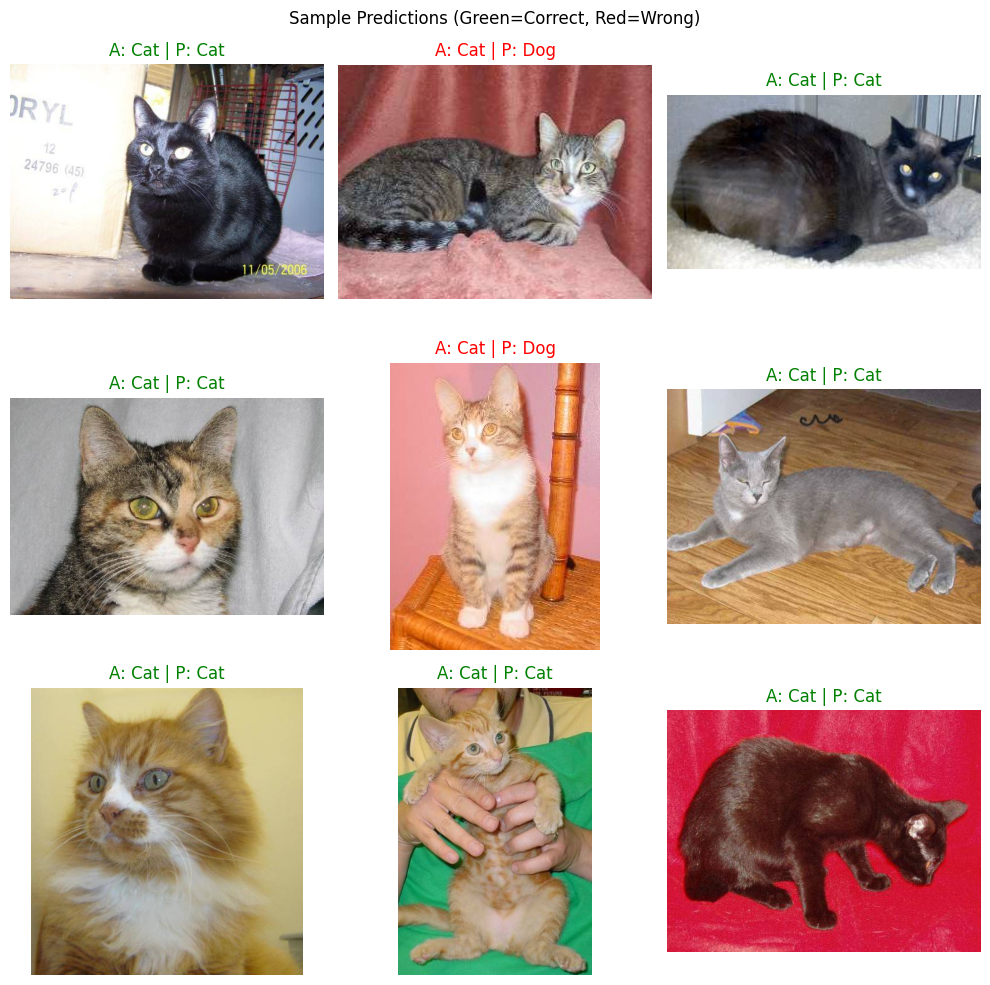

cat.10003.jpg --> Predicted: Cat


In [ ]:
# SKILLCRAFT TECHNOLOGY – TASK 03
# SVM Image Classification – Dogs vs Cats
# Joshua Pinto
# Dataset: Dogs vs Cats (Kaggle)

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


IMG_SIZE = 64
MAX_IMAGES_PER_CLASS = 1000  # 1000 cats + 1000 dogs = 2000 total
train_dir = r'C:\Users\hp\Desktop\Internship\task 3\train'

# Load Data
data, labels = [], []
cat_count, dog_count = 0, 0

for img_name in os.listdir(train_dir):
    is_cat = img_name.startswith('cat')
    is_dog = img_name.startswith('dog')

    if is_cat and cat_count >= MAX_IMAGES_PER_CLASS: continue
    if is_dog and dog_count >= MAX_IMAGES_PER_CLASS: continue

    img = cv2.imread(os.path.join(train_dir, img_name))
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    data.append(img.flatten())
    labels.append(0 if is_cat else 1)

    if is_cat: cat_count += 1
    if is_dog: dog_count += 1

print(f"Cats: {cat_count} | Dogs: {dog_count} | Total: {len(data)}")

X, y = np.array(data), np.array(labels)

# Preprocessing 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=100, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance retained by PCA: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Train/Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# Train SVM 
print("\nTraining SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
print("Training complete.")

# Evaluate 
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Cat', 'Dog']))

# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])
plt.title('Confusion Matrix – SVM (RBF Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Sample Predictions 
sample_imgs = os.listdir(train_dir)[:9]
plt.figure(figsize=(10, 10))
for i, img_name in enumerate(sample_imgs):
    img_path = os.path.join(train_dir, img_name)
    img_orig = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img_orig, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE)).flatten().reshape(1, -1)
    img_scaled = scaler.transform(img_resized)
    img_pca = pca.transform(img_scaled)
    pred = svm.predict(img_pca)[0]
    actual = 'Dog' if img_name.startswith('dog') else 'Cat'
    predicted = 'Dog' if pred == 1 else 'Cat'
    color = 'green' if actual == predicted else 'red'
    plt.subplot(3, 3, i + 1)
    plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
    plt.title(f'A: {actual} | P: {predicted}', color=color)
    plt.axis('off')
plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.show()

# Custom Prediction 
def predict_image(img_path):
    img = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE)).flatten().reshape(1, -1)
    img_scaled = scaler.transform(img_resized)
    img_pca = pca.transform(img_scaled)
    pred = svm.predict(img_pca)[0]
    result = 'Dog' if pred == 1 else 'Cat'
    print(f"{os.path.basename(img_path)} --> Predicted: {result}")

predict_image(os.path.join(train_dir, os.listdir(train_dir)[0]))